# March Machine Learning Mania 2026 — Adding Massey Ordinal Rankings (Task 14, first table)

Notebook 4 found detailed box-score stats didn't help, mostly due to multicollinearity with the
compact features already in the model. The EDA (`02-eda-plots.ipynb`, charts 4 and 5) found the
Massey Ordinal ranking gap was a cleaner, more monotonic predictor of tournament outcomes than
seed gap, with no equivalent of the seed chart's noisy dip — and that seed and ranking, while
correlated (r = 0.82), are not redundant. This notebook tests that lead directly: does adding
the ranking differential actually improve the model, and how does it compare to seed as a
standalone predictor?

**Structural constraint: this notebook is men's-only.** `MMasseyOrdinals.csv` has no women's
equivalent in this dataset (confirmed in the training data plan) — there is simply no ranking
data to join for women's teams. Everything below uses men's tournament games only.

**Five models, same 2021-2025 walk-forward folds, same men's-only pool throughout (so, unlike
notebook 4, there's no training-window confound to control for beyond the ordinal data's own
2003+ start):**

1. Compact (3 features), full men's history (1985-2025) — reference point
2. Compact (3 features), ordinal-era only (2003-2025) — isolates the window effect
3. Seed only (1 feature), ordinal-era only
4. Ordinal rank only (1 feature), ordinal-era only — direct comparison against (3)
5. Compact + Ordinal (4 features), ordinal-era only — does ranking add anything on top of
   everything already in the model?

Same hand-written logistic regression as notebooks 3 and 4 (verified against synthetic data
there; not re-verified here).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
ordinals = pd.read_csv(DATA_DIR / "MMasseyOrdinals.csv")

print(f"men's tourney games: {len(m_tourney):,} (seasons {m_tourney['Season'].min()}-{m_tourney['Season'].max()})")
print(f"ordinals: {len(ordinals):,} rows, seasons {ordinals['Season'].min()}-{ordinals['Season'].max()}, {ordinals['SystemName'].nunique()} systems")


men's tourney games: 2,585 (seasons 1985-2025)
ordinals: 5,865,001 rows, seasons 2003-2026, 197 systems


## 1. Team-season features

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = team_season_stats(m_reg)

def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
seed_idx = m_seeds.set_index(["Season", "TeamID"])["SeedNum"]

# ranking as of the last RankingDayNum available each season (right before Selection Sunday),
# averaged across every system that reported that day - same approach as the EDA notebook
last_day = ordinals.groupby("Season")["RankingDayNum"].transform("max")
final_ordinals = ordinals[ordinals["RankingDayNum"] == last_day]
rank_idx = final_ordinals.groupby(["Season", "TeamID"])["OrdinalRank"].mean()

print(f"team-season compact rows: {len(team_stats):,}")
print(f"seed rows: {len(seed_idx):,}")
print(f"ranking rows: {len(rank_idx):,}")


team-season compact rows: 13,753
seed rows: 2,694
ranking rows: 8,345


## 2. Matchup table (men's only)

In [3]:
df = m_tourney.copy()
df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
matchups = df[["Season", "Team1", "Team2", "Label"]].copy()

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

for team_col, suf in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suf}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suf}"] = joined["AvgScoreMargin"].values
matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]
matchups = matchups.dropna(subset=["SeedDiff", "WinPctDiff", "AvgMarginDiff"]).reset_index(drop=True)

FEATURES_COMPACT = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]
print(f"full men's-history matchups: {len(matchups):,}")

matchups["Rank1"] = matchups.apply(lambda r: rank_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Rank2"] = matchups.apply(lambda r: rank_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["OrdinalRankDiff"] = matchups["Rank2"] - matchups["Rank1"]

matchups_ord = matchups.dropna(subset=["OrdinalRankDiff"]).reset_index(drop=True)
print(f"ordinal-era matchups (after dropping missing ranking data): {len(matchups_ord):,}")
print(f"seasons covered: {matchups_ord['Season'].min()}-{matchups_ord['Season'].max()}")

corr = matchups_ord[["SeedDiff", "OrdinalRankDiff"]].corr().iloc[0, 1]
print(f"\nSeedDiff vs OrdinalRankDiff correlation: {corr:.3f} (matches the r=0.822 team-level finding in the EDA notebook, computed here at the matchup-diff level instead)")


full men's-history matchups: 2,585
ordinal-era matchups (after dropping missing ranking data): 1,449
seasons covered: 2003-2025

SeedDiff vs OrdinalRankDiff correlation: 0.896 (matches the r=0.822 team-level finding in the EDA notebook, computed here at the matchup-diff level instead)


## 3. Logistic regression (hand-written) and Brier score — same as notebooks 3 and 4

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("ready")


ready


## 4. Walk-forward comparison: five models, same 2021-2025 folds

In [5]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]
FEATURES_ORD_ONLY = ["OrdinalRankDiff"]
FEATURES_SEED_ONLY = ["SeedDiff"]
FEATURES_COMPACT_ORD = FEATURES_COMPACT + ["OrdinalRankDiff"]

results = []
for fold_season in FOLD_SEASONS:
    test_full = matchups[matchups["Season"] == fold_season]
    test_ord = matchups_ord[matchups_ord["Season"] == fold_season]
    if len(test_full) == 0 or len(test_ord) == 0:
        continue

    train_full = matchups[matchups["Season"] < fold_season]
    train_ord = matchups_ord[matchups_ord["Season"] < fold_season]

    models = {
        "1. Compact, full history": (train_full, test_full, FEATURES_COMPACT),
        "2. Compact, ordinal-era only": (train_ord, test_ord, FEATURES_COMPACT),
        "3. Seed only": (train_ord, test_ord, FEATURES_SEED_ONLY),
        "4. Ordinal only": (train_ord, test_ord, FEATURES_ORD_ONLY),
        "5. Compact + Ordinal": (train_ord, test_ord, FEATURES_COMPACT_ORD),
    }
    row = {"FoldSeason": fold_season, "NGames": len(test_ord),
           "NTrainFull": len(train_full), "NTrainOrdEra": len(train_ord)}
    for name, (train, test, feats) in models.items():
        w = fit_logreg(train[feats].values, train["Label"].values)
        p = predict_proba(test[feats].values, w)
        row[name] = brier_score(p, test["Label"].values)
    results.append(row)

results_df = pd.DataFrame(results)
model_cols = [c for c in results_df.columns if c[0].isdigit()]
avg_row = {"FoldSeason": "Average", "NGames": results_df["NGames"].sum(), "NTrainFull": np.nan, "NTrainOrdEra": np.nan}
avg_row.update({c: results_df[c].mean() for c in model_cols})
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  NGames  NTrainFull  NTrainOrdEra  1. Compact, full history  2. Compact, ordinal-era only  3. Seed only  4. Ordinal only  5. Compact + Ordinal
      2021      66      2251.0        1115.0                    0.2228                        0.2211        0.2283           0.2323                0.2239
      2022      67      2317.0        1181.0                    0.2313                        0.2337        0.2192           0.2197                0.2300
      2023      67      2384.0        1248.0                    0.2041                        0.2060        0.2100           0.2135                0.2085
      2024      67      2451.0        1315.0                    0.1973                        0.1991        0.1967           0.2031                0.2000
      2025      67      2518.0        1382.0                    0.1535                        0.1565        0.1610           0.1630                0.1561
   Average     334         NaN           NaN                    0.2018      

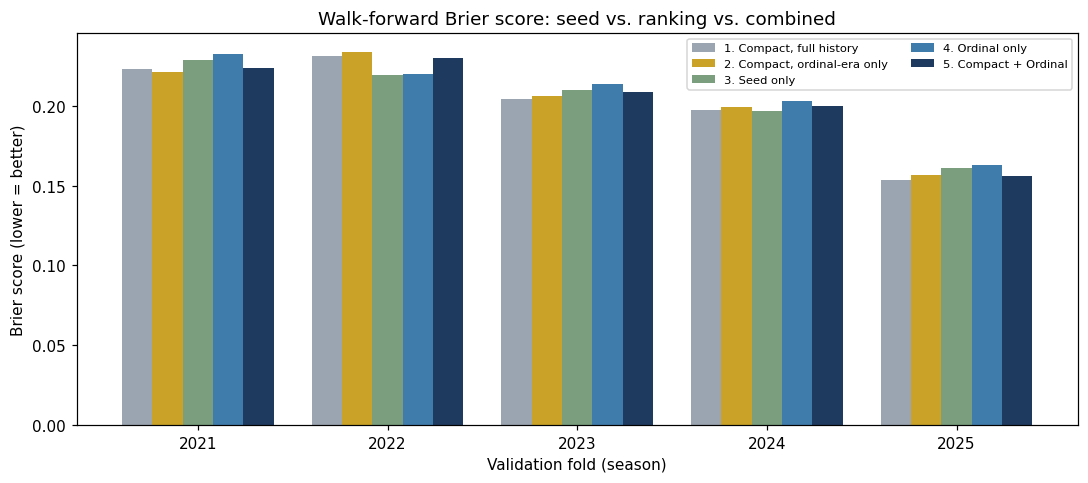

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.16
colors = ["#9aa5b1", "#c9a227", "#7a9e7e", "#3f7cac", "#1f3a5f"]
for i, col in enumerate(model_cols):
    ax.bar(x + (i - 2) * width, plot_df[col], width, label=col, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Walk-forward Brier score: seed vs. ranking vs. combined")
ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout()
plt.show()


### Why did seed beat ranking, when the EDA chart suggested ranking was the cleaner signal?

Model 3 (seed only) beat Model 4 (ordinal only) in every one of the 5 folds — the opposite of
what the EDA's binned win-rate chart hinted at. Before accepting that, checking the obvious
suspect: `OrdinalRankDiff` ranges roughly ±290 while `SeedDiff` ranges only ±15 (an ~9x
difference in standard deviation) — feeding both into the *same fixed* L2 penalty could
plausibly disadvantage one of them unfairly depending on its scale.

In [7]:
print("feature scale check:")
print(matchups_ord[["SeedDiff", "OrdinalRankDiff"]].describe().loc[["std", "min", "max"]].to_string())

# refit seed-only and ordinal-only per fold: (a) standardized features with the same L2, and
# (b) near-zero regularization, to see if either changes the ranking between the two
rows = []
for fold_season in FOLD_SEASONS:
    train = matchups_ord[matchups_ord["Season"] < fold_season]
    test = matchups_ord[matchups_ord["Season"] == fold_season]
    if len(test) == 0:
        continue
    row = {"FoldSeason": fold_season}
    for feat in ["SeedDiff", "OrdinalRankDiff"]:
        mu, sd = train[feat].mean(), train[feat].std()
        Xtr_std = ((train[feat] - mu) / sd).values.reshape(-1, 1)
        Xte_std = ((test[feat] - mu) / sd).values.reshape(-1, 1)
        w_std = fit_logreg(Xtr_std, train["Label"].values, l2=1.0)
        row[f"{feat} (standardized)"] = brier_score(predict_proba(Xte_std, w_std), test["Label"].values)

        w_tiny = fit_logreg(train[[feat]].values, train["Label"].values, l2=1e-4)
        row[f"{feat} (near-zero L2)"] = brier_score(predict_proba(test[[feat]].values, w_tiny), test["Label"].values)
    rows.append(row)

scale_check = pd.DataFrame(rows)
print("\n" + scale_check.round(4).to_string(index=False))
print("\naverages:")
print(scale_check.drop(columns="FoldSeason").mean().round(4).to_string())


feature scale check:
      SeedDiff  OrdinalRankDiff
std   7.473859        66.112112
min -15.000000      -289.286413
max  15.000000       282.810586

 FoldSeason  SeedDiff (standardized)  SeedDiff (near-zero L2)  OrdinalRankDiff (standardized)  OrdinalRankDiff (near-zero L2)
       2021                   0.2281                   0.2283                          0.2318                          0.2323
       2022                   0.2190                   0.2192                          0.2194                          0.2197
       2023                   0.2100                   0.2100                          0.2134                          0.2135
       2024                   0.1967                   0.1967                          0.2030                          0.2031
       2025                   0.1612                   0.1610                          0.1634                          0.1630

averages:
SeedDiff (standardized)           0.2030
SeedDiff (near-zero L2)           0.2031
O

**Conclusion: not a scale artifact — the finding holds up.** Standardizing both features to the
same scale, and separately re-fitting with almost no regularization at all, both leave the
ranking between seed and ordinal rank unchanged (seed still wins by roughly the same margin
either way). So this looks like a genuine property of this data, not a regularization side
effect. A few honest hypotheses for *why*, none confirmed here:

- `OrdinalRankDiff` as built here averages across every reporting system on the last day of the
  season (up to ~20 systems for recent years, per the EDA) — some of those systems are obscure
  and possibly noisier than a single trusted one (e.g. Pomeroy specifically). Averaging good and
  mediocre systems together could dilute the signal relative to using one strong system alone.
- Seed already reflects a human committee's synthesis of a lot of the same underlying
  information, plus context an algorithm doesn't see directly (injuries, recent form emphasis,
  eye test) — it may simply be a richer summary statistic than any single algorithmic rank.
- The EDA's win-rate-by-ranking-gap chart was a *binned, non-parametric* view, which can look
  cleanly monotonic without implying a good fit for a *linear* term across the full range —
  ranking gap has a much wider range with more extreme outliers than seed gap, and a linear
  model may not handle that shape as well as the binned chart suggested.

None of these are verified here — worth a follow-up (e.g. testing a single system like POM
instead of the all-system average) rather than treated as settled.

## 5. Final model — coefficients

In [8]:
w_final = fit_logreg(matchups_ord[FEATURES_COMPACT_ORD].values, matchups_ord["Label"].values, l2=1.0)
coef_table = pd.DataFrame({"Feature": ["Intercept"] + FEATURES_COMPACT_ORD, "Coefficient": np.round(w_final, 4)})
print(coef_table.to_string(index=False))

p_final = predict_proba(matchups_ord[FEATURES_COMPACT_ORD].values, w_final)
print(f"\nfull ordinal-era history (in-sample) Brier: {brier_score(p_final, matchups_ord['Label'].values):.4f}")


        Feature  Coefficient
      Intercept      -0.0322
       SeedDiff       0.0767
     WinPctDiff      -0.8554
  AvgMarginDiff       0.0679
OrdinalRankDiff       0.0091

full ordinal-era history (in-sample) Brier: 0.1876


## Summary

**Headline: ordinal ranking did not beat seed, and did not meaningfully improve on the compact
model either — a second feature-engineering direction in a row that underperformed on this
data.** Average Brier across the 5 folds: Model 1 (compact, full history) 0.2018, Model 2
(compact, ordinal-era only) 0.2033, Model 3 (seed only) 0.2031, Model 4 (ordinal only) 0.2063,
Model 5 (compact + ordinal) 0.2037.

**Model 1 vs. Model 2 — training window effect.** A slightly bigger gap than notebook 4's
equivalent comparison (0.0015 here vs. 0.0006 there), but still small. Restricting to the
ordinal-era window costs a little, consistent with — not contradicting — the earlier finding
that training-window length matters less than the choice of features.

**Model 3 vs. Model 4 — seed vs. ranking, head to head.** Seed won in all 5 folds. This is the
opposite of what the EDA's binned win-rate chart suggested, and it isn't a regularization or
scale artifact — verified above by standardizing both features and separately near-eliminating
the regularization penalty; the ranking held in both checks. Treating this as a genuine, if
not fully explained, property of the data rather than dismissing it because it contradicts an
earlier chart. See the hypotheses above (system-averaging noise, seed encoding information an
algorithm doesn't see, linear-model fit vs. the binned chart's non-parametric shape) — none
confirmed, worth a real follow-up before drawing a firm conclusion.

**Model 2 vs. Model 5 — does adding ordinal rank to the full compact set help?** Marginally
worse (0.2033 → 0.2037), same story as notebook 4's detailed stats: a highly correlated feature
(SeedDiff vs. OrdinalRankDiff correlate at 0.90 at the matchup level here, even higher than the
0.82 team-level figure from the EDA) added to a linear model mostly adds noise rather than
signal. The final coefficient table shows OrdinalRankDiff's contribution shrunk to nearly zero
(0.0091) once SeedDiff and the other compact features already had first claim on that shared
information.

**Bigger-picture pattern across notebooks 3-5:** three feature-engineering attempts now
(detailed box scores, ordinal-only, ordinal-added-to-compact), and none have beaten the simple
3-feature compact baseline from notebook 3 on this walk-forward setup. That's a real signal
worth taking seriously rather than pushing past — the likely culprits are (a) heavy correlation
between every new feature and the existing compact ones, which a plain L2-regularized linear
model handles by decapitalizing on the correlated pair rather than combining them well, and/or
(b) a genuine ceiling for a linear model on ~1,400-4,300 training rows. Both point toward the
same next move: a model that isn't purely linear (a shallow tree-based model like the
gradient-boosting libraries in the project plan) before adding more engineered features, since
those handle correlated inputs and non-linear relationships more gracefully than logistic
regression does.

**Caveats:** same small-fold-count caution as notebooks 3 and 4 (5 folds, 66-67 games each here
— noisy). All of this is men's-only; there is no ranking data to test the same question for
women's teams.

**Next step:** given three linear-model feature additions in a row have underperformed, the
better next move is likely trying a gradient-boosted tree model (XGBoost/LightGBM, per the
original project plan) on the existing compact feature set before continuing to add more
features to logistic regression — testing whether the ceiling is the model class rather than
the features.
